In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
sys.path.append(os.path.abspath(".."))

In [7]:
from src.data_preprocessing import load_data

df = load_data("../data/raw/raw_clothing_prices.csv")
df.head()

,Brand,Category,Color,Size,Material,Price
0,New Balance,Dress,White,XS,Nylon,182
1,New Balance,Jeans,Black,XS,Silk,57
2,Under Armour,Dress,Red,M,Wool,127
3,Nike,Shoes,Green,M,Cotton,77
4,Adidas,Sweater,White,M,Nylon,113


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Brand     1000 non-null   category
 1   Category  1000 non-null   category
 2   Color     1000 non-null   category
 3   Size      1000 non-null   category
 4   Material  1000 non-null   category
 5   Price     1000 non-null   int64   
dtypes: category(5), int64(1)
memory usage: 13.2 KB


In [9]:
df.describe()

,Price
count,1000.000000
mean,106.289000
std,53.695444
min,10.000000
25%,59.750000
50%,108.000000
75%,150.000000
max,199.000000


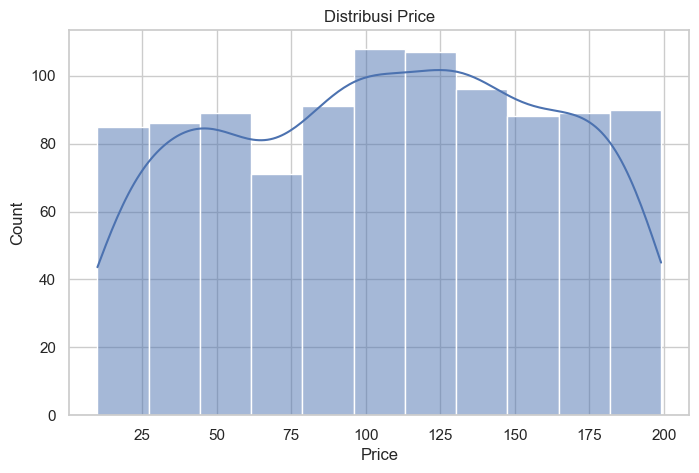

In [10]:
sns.histplot(df['Price'], kde=True)
plt.title("Distribusi Price")
plt.show()

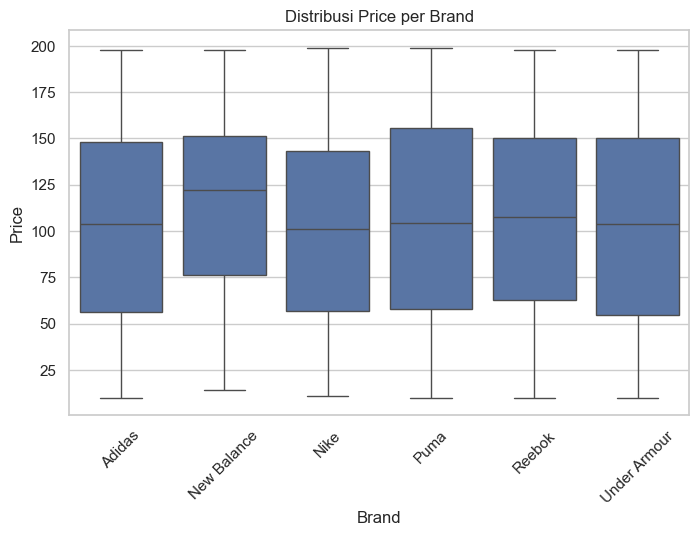

In [11]:
sns.boxplot(x='Brand', y='Price', data=df)
plt.xticks(rotation=45)
plt.title("Distribusi Price per Brand")
plt.show()

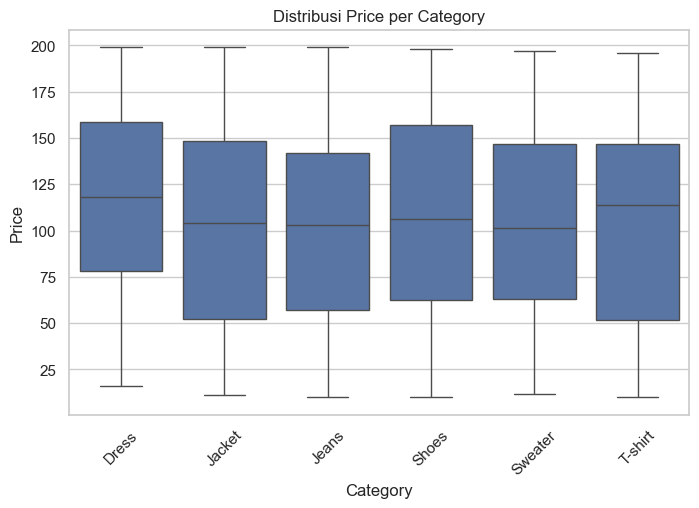

In [12]:
sns.boxplot(x='Category', y='Price', data=df)
plt.xticks(rotation=45)
plt.title("Distribusi Price per Category")
plt.show()

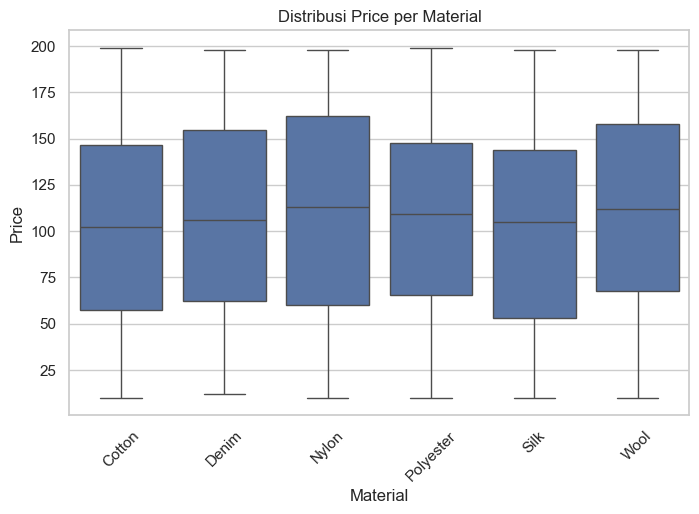

In [13]:
sns.boxplot(x='Material', y='Price', data=df)
plt.xticks(rotation=45)
plt.title("Distribusi Price per Material")
plt.show()

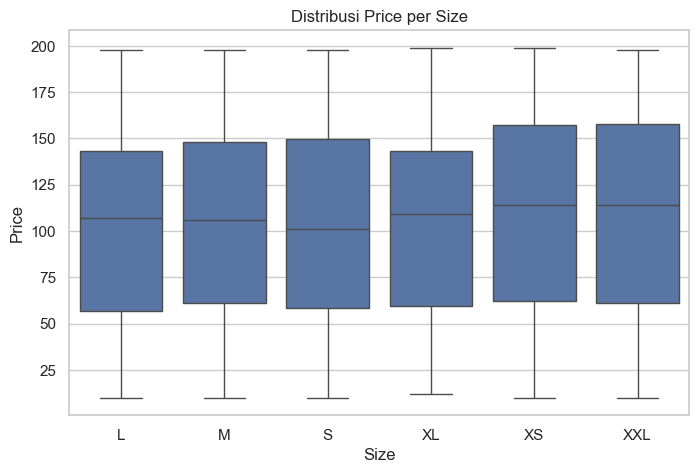

In [14]:
sns.boxplot(x='Size', y='Price', data=df)
plt.title("Distribusi Price per Size")
plt.show()

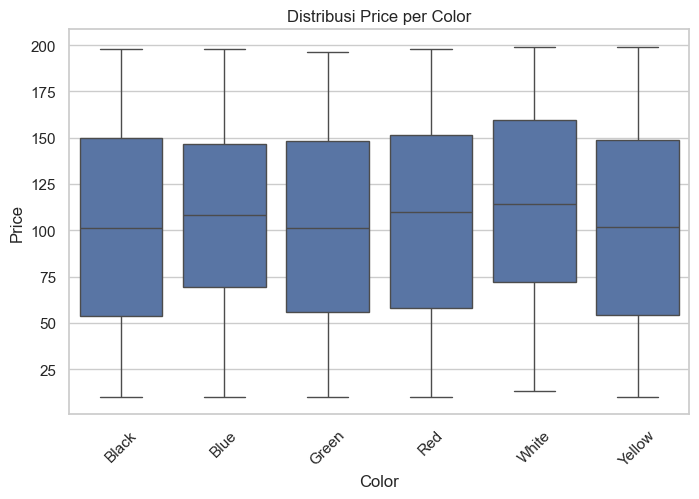

In [15]:
sns.boxplot(x='Color', y='Price', data=df)
plt.xticks(rotation=45)
plt.title("Distribusi Price per Color")
plt.show()

In [16]:
for col in ['Brand', 'Category', 'Material']:
    print(f"\nMean Price per {col}:")
    print(df.groupby(col)['Price'].mean())


Mean Price per Brand:
Brand
Adidas          104.054217
New Balance     115.457317
Nike            101.909091
Puma            106.136905
Reebok          106.493671
Under Armour    103.960894
Name: Price, dtype: float64

Mean Price per Category:
Category
Dress      114.506024
Jacket     102.827225
Jeans      100.748503
Shoes      108.569767
Sweater    106.781250
T-shirt    104.562500
Name: Price, dtype: float64

Mean Price per Material:
Material
Cotton       103.345679
Denim        107.687117
Nylon        109.387097
Polyester    106.434286
Silk         101.913295
Wool         109.197674
Name: Price, dtype: float64


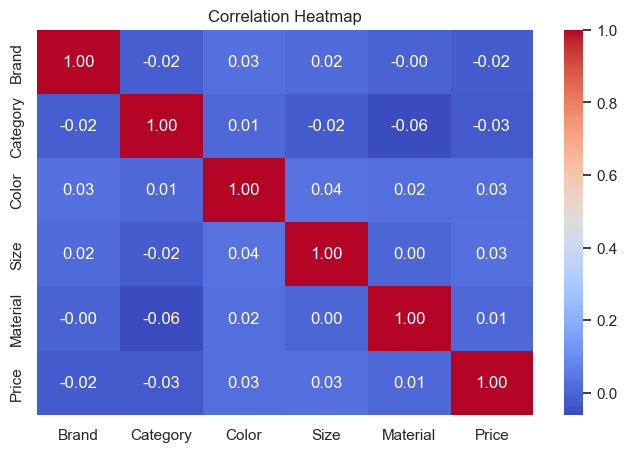

In [17]:
df_encoded = df.copy()

for col in ['Brand', 'Category', 'Color', 'Size', 'Material']:
    df_encoded[col] = df_encoded[col].cat.codes

corr = df_encoded.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [18]:
df['Price'].var()

np.float64(2883.2006796796795)